# Notebook 1 — Mary's clinical odyssey begins
## Processes, their parts, when they happen, in what order

Mary is 52. On 2026-02-18 she arrives at the outpatient gynecology clinic for a routine examination. Eight months later she will be in remission. Between those two dates a sequence of clinical *processes* will unfold — an examination, an ultrasound, a biopsy, a diagnosis, several months of chemotherapy, a surgery, a follow-up. By the end of this notebook we will have asserted the entire **shape** of Mary's care timeline: every process, its internal structure, its timestamps, and the order in which the processes occur.

We will not yet model the people who participate in these processes — that is NB2. We will not yet model Mary's anatomy — that is NB3. We will not yet model her qualities and quantities — that is NB4. The pedagogic insight of NB1 is that **the temporal shape of clinical care can be modelled independently of its participants**. This separation is one of SULO's design strengths.

## Learning objectives

1. Declare clinical events as subclasses of `sulo:Process`
2. Express the internal structure of a process using `sulo:hasDirectPart` with cardinality restrictions
3. Anchor processes in time using `sulo:atTime` together with `sulo:TimeInstant`, `sulo:StartTime`, and `sulo:EndTime`
4. Order processes **at the individual level** using `sulo:precedes`
5. Compute the *transitive closure* of those orderings at **query time** using a SPARQL property path — without introducing any new property or modifying SULO
6. Save the resulting ontology as `mie-01.owl` for use by the rest of the tutorial

## A note on what we will *not* do

Two temptations are explicitly avoided.

1. **No class-level `precedes` axioms.** Writing `Biopsy is_a [precedes some Histopathology]` is an existential restriction that conjures anonymous witnesses where none exist (research biopsies, abandoned biopsies). It also conflates *what actually happened* with *what the protocol says should happen*. We assert `precedes` strictly on individuals.
2. **No new object or data properties beyond what SULO ships.** This whole notebook uses only `sulo:hasDirectPart`, `sulo:atTime`, `sulo:hasValue`, and `sulo:precedes`. Where SULO does not give us transitive closure (`sulo:precedes` is not declared transitive), we recover it at *query time* using SPARQL — not by introducing a sub-property.

## Setting up the environment

We load SULO (the upper-level ontology), create a fresh MIE-tutorial extension ontology, and import SULO into it. Subsequent notebooks will reload the saved checkpoint produced at the end of this notebook.

In [1]:
import sys, os, datetime
# Locate the project root (the directory containing lib/) regardless of CWD
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *
onto_path.append("dist")

sulo = get_ontology("dist/sulo.owl").load()

mie = get_ontology("https://w3id.org/ontostart/mie/")
mie.imported_ontologies.append(sulo)

print(f"SULO loaded: {len(list(sulo.classes()))} classes")
print(f"MIE ontology: {mie.base_iri}")

SULO loaded: 17 classes
MIE ontology: https://w3id.org/ontostart/mie/


## Mary's odyssey at a glance

| Date | Event | SULO category |
|---|---|---|
| 2026-02-18 | Routine gynecologic visit including a manual breast examination | `Process` |
| 2026-02-20 | Ultrasound of the left breast | `Process` |
| 2026-02-22 | Diagnostic assessment (provisional) | `Process` |
| 2026-02-25 | Core needle biopsy of the left breast | `Process` |
| 2026-03-01 | Histopathological analysis + diagnostic assessment (confirmed) | `Process` |
| 2026-03-10 → 2026-06-15 | Neoadjuvant chemotherapy | `Process` with `StartTime` and `EndTime` |
| 2026-07-01 | Lumpectomy of the left breast | `Process` |
| 2026-09-30 | Follow-up visit (remission) | `Process` |

Throughout the tutorial we keep all clinical class names prefixed with `SCT_` to signal that each is intended to align with an existing SNOMED CT concept. The MIE tutorial defines them locally; in a production ontology these would be MIREOT-imported.

## §1 — Declaring the clinical processes

Every event in Mary's odyssey is a **process** — a temporally extended occurrent that brings entities into existence, modifies them, or relates them. We declare each as a direct subclass of `sulo:Process`. At this stage we do not commit to any internal structure or participants; we are simply naming the kinds of things that can happen.

Two events of note:

- `SCT_DiagnosticAssessment` will occur **twice** in Mary's timeline (Feb 22 preliminary, Mar 1 confirmed). This is appropriate: the *class* is one, the *individuals* are two.
- `SCT_NeoadjuvantAntineoplasticChemotherapy` is a single process that *extends over time*. Its temporal anchor will be a `StartTime` and an `EndTime`, not a `TimeInstant`.

In [2]:
with mie:
    class SCT_RoutineGynecologicExamination(sulo.Process):
        """A planned periodic examination of a patient by a gynecologist, comprising a physical examination and clinical documentation."""
        label = [locstr("routine gynecologic examination", "en")]

    class SCT_PhysicalExamination(sulo.Process):
        """A clinical examination of the patient's body by inspection, palpation, percussion and auscultation."""
        label = [locstr("physical examination", "en")]

    class SCT_ManualBreastExamination(sulo.Process):
        """A focused palpation of one or both breasts and the regional lymph nodes."""
        label = [locstr("manual breast examination", "en")]

    class SCT_ClinicalDocumentation(sulo.Process):
        """The act of recording clinical observations made during a process into the patient record."""
        label = [locstr("clinical documentation", "en")]

    class SCT_UltrasonographyOfLeftBreast(sulo.Process):
        """Diagnostic ultrasonography focused on the tissues of the left breast."""
        label = [locstr("ultrasonography of left breast", "en")]

    class SCT_DiagnosticAssessment(sulo.Process):
        """A clinical reasoning process by which a clinician forms a diagnostic judgment from available evidence."""
        label = [locstr("diagnostic assessment", "en")]

    class SCT_CoreNeedleBiopsyOfBreast(sulo.Process):
        """A percutaneous procedure that removes a cylindrical tissue sample from the breast for pathological analysis."""
        label = [locstr("core needle biopsy of breast", "en")]

    class SCT_HistopathologyTest(sulo.Process):
        """Laboratory examination of a tissue specimen to characterise cellular and structural abnormalities."""
        label = [locstr("histopathology test", "en")]

    class SCT_NeoadjuvantAntineoplasticChemotherapy(sulo.Process):
        """Cytotoxic drug therapy administered before primary surgical treatment with the aim of reducing tumour burden."""
        label = [locstr("neoadjuvant antineoplastic chemotherapy", "en")]

    class SCT_LumpectomyOfLeftBreast(sulo.Process):
        """Surgical excision of a localised lesion from the left breast, preserving the surrounding tissue."""
        label = [locstr("lumpectomy of left breast", "en")]

    class SCT_FollowUpVisit(sulo.Process):
        """A subsequent clinical encounter to assess disease status after a prior intervention."""
        label = [locstr("follow-up visit", "en")]

print(f"Declared {len(list(mie.classes()))} processes for Mary's odyssey")

Declared 11 processes for Mary's odyssey


## §2 — Processes have parts

Parthood is not only for spatial objects. Processes also decompose into sub-processes, and SULO's `hasPart` / `hasDirectPart` properties apply to both. For Mary's first visit:

- A `SCT_RoutineGynecologicExamination` **directly has** exactly one `SCT_PhysicalExamination` as a sub-process and at most one `SCT_ClinicalDocumentation`.
- A `SCT_PhysicalExamination` **directly has** at most one `SCT_ManualBreastExamination` as a sub-process (a patient's full physical exam may include the breast exam but need not).

### Why `hasDirectPart` rather than `hasPart`?

`sulo:hasPart` is declared **transitive** in SULO. Transitive properties cannot bear cardinality restrictions in OWL 2 DL — combining the two violates the profile and breaks reasoning. `sulo:hasDirectPart` is its non-transitive sub-property, designed exactly for cardinality-bearing parthood claims. This is the same lesson taught in the SULO Pizza tutorial: any time a cardinality is involved, reach for `hasDirectPart`.

In [3]:
with mie:
    SCT_RoutineGynecologicExamination.is_a.append(
        sulo.hasDirectPart.exactly(1, SCT_PhysicalExamination)
    )
    SCT_RoutineGynecologicExamination.is_a.append(
        sulo.hasDirectPart.max(1, SCT_ClinicalDocumentation)
    )
    SCT_PhysicalExamination.is_a.append(
        sulo.hasDirectPart.max(1, SCT_ManualBreastExamination)
    )

print("Restrictions on SCT_RoutineGynecologicExamination:")
for r in SCT_RoutineGynecologicExamination.is_a:
    print("  ", r)
print("\nRestrictions on SCT_PhysicalExamination:")
for r in SCT_PhysicalExamination.is_a:
    print("  ", r)

Restrictions on SCT_RoutineGynecologicExamination:
   sulo.Process
   sulo.hasDirectPart.exactly(1, mie.SCT_PhysicalExamination)
   sulo.hasDirectPart.max(1, mie.SCT_ClinicalDocumentation)

Restrictions on SCT_PhysicalExamination:
   sulo.Process
   sulo.hasDirectPart.max(1, mie.SCT_ManualBreastExamination)


## §3 — Anchoring a process in time

Processes occur **at** times. In SULO this is `sulo:atTime`, whose range is `sulo:Time`. SULO offers four temporal sub-classes you will use throughout the tutorial:

| Class | When to use |
|---|---|
| `sulo:TimeInstant` | A point in time — appropriate for instantaneous or short clinical events |
| `sulo:StartTime` | The first instant of an extended process |
| `sulo:EndTime` | The last instant of an extended process |
| `sulo:Duration` | A length of time between two instants (introduced in NB4) |

Each time entity carries a value via `sulo:hasValue` — a **functional** data property. In owlready2 we assign `datetime.datetime(...)` directly.

### Mary's first visit

Mary arrives at the clinic at 09:00 on 2026-02-18 and leaves at 10:30. We create the visit individual, give it a `StartTime` and an `EndTime`, and attach the documentation sub-process as a part.

In [4]:
with mie:
    # The visit individual
    mary_visit_feb18 = SCT_RoutineGynecologicExamination("mary_visit_feb18")
    mary_visit_feb18.label = [locstr("Mary's routine gynecologic visit, 2026-02-18", "en")]

    visit_start = sulo.StartTime("mary_visit_feb18_start")
    visit_start.hasValue = datetime.datetime(2026, 2, 18, 9, 0)

    visit_end = sulo.EndTime("mary_visit_feb18_end")
    visit_end.hasValue = datetime.datetime(2026, 2, 18, 10, 30)

    mary_visit_feb18.atTime = [visit_start, visit_end]

    # The physical exam and the manual breast exam as sub-processes
    mary_phys_exam = SCT_PhysicalExamination("mary_phys_exam_feb18")
    mary_breast_exam = SCT_ManualBreastExamination("mary_breast_exam_feb18")
    mary_phys_exam.hasDirectPart = [mary_breast_exam]
    mary_visit_feb18.hasDirectPart = [mary_phys_exam]

    # Documentation step
    mary_doc_feb18 = SCT_ClinicalDocumentation("mary_doc_feb18")
    mary_visit_feb18.hasDirectPart.append(mary_doc_feb18)

print(f"Visit start: {visit_start.hasValue}")
print(f"Visit end:   {visit_end.hasValue}")
print(f"Direct parts of the visit: {[p.name for p in mary_visit_feb18.hasDirectPart]}")
print(f"Direct parts of the physical exam: {[p.name for p in mary_phys_exam.hasDirectPart]}")

Visit start: 2026-02-18 09:00:00
Visit end:   2026-02-18 10:30:00
Direct parts of the visit: ['mary_phys_exam_feb18', 'mary_doc_feb18']
Direct parts of the physical exam: ['mary_breast_exam_feb18']


## §4 — The full odyssey on a timeline

We now create one individual per remaining event in Mary's odyssey. Most are anchored to a single `TimeInstant`; the chemotherapy is anchored to a `StartTime` and an `EndTime` because it extends over fourteen weeks. Notice that `SCT_DiagnosticAssessment` is instantiated twice — once on Feb 22 (preliminary) and once on Mar 1 (confirmed). The class is one; the individuals are two.

In [5]:
with mie:

    def _instant(name, dt):
        t = sulo.TimeInstant(name)
        t.hasValue = dt
        return t

    # 2026-02-20 — ultrasound
    mary_ultrasound = SCT_UltrasonographyOfLeftBreast("mary_ultrasound_feb20")
    mary_ultrasound.atTime = [_instant("t_2026_02_20", datetime.datetime(2026, 2, 20, 11, 0))]

    # 2026-02-22 — preliminary diagnostic assessment
    mary_diag_prelim = SCT_DiagnosticAssessment("mary_diag_feb22_preliminary")
    mary_diag_prelim.atTime = [_instant("t_2026_02_22", datetime.datetime(2026, 2, 22, 14, 0))]

    # 2026-02-25 — biopsy
    mary_biopsy = SCT_CoreNeedleBiopsyOfBreast("mary_biopsy_feb25")
    mary_biopsy.atTime = [_instant("t_2026_02_25", datetime.datetime(2026, 2, 25, 9, 30))]

    # 2026-03-01 — histopathology + confirmed diagnosis
    mary_histo = SCT_HistopathologyTest("mary_histo_mar01")
    mary_histo.atTime = [_instant("t_2026_03_01_lab", datetime.datetime(2026, 3, 1, 12, 0))]

    mary_diag_confirm = SCT_DiagnosticAssessment("mary_diag_mar01_confirmed")
    mary_diag_confirm.atTime = [_instant("t_2026_03_01", datetime.datetime(2026, 3, 1, 16, 0))]

    # 2026-03-10 → 2026-06-15 — chemotherapy with StartTime and EndTime
    mary_chemo = SCT_NeoadjuvantAntineoplasticChemotherapy("mary_chemo_2026")
    chemo_start = sulo.StartTime("mary_chemo_start")
    chemo_start.hasValue = datetime.datetime(2026, 3, 10, 8, 0)
    chemo_end = sulo.EndTime("mary_chemo_end")
    chemo_end.hasValue = datetime.datetime(2026, 6, 15, 17, 0)
    mary_chemo.atTime = [chemo_start, chemo_end]

    # 2026-07-01 — lumpectomy
    mary_lumpectomy = SCT_LumpectomyOfLeftBreast("mary_lumpectomy_jul01")
    mary_lumpectomy.atTime = [_instant("t_2026_07_01", datetime.datetime(2026, 7, 1, 8, 0))]

    # 2026-09-30 — follow-up
    mary_followup = SCT_FollowUpVisit("mary_followup_sep30")
    mary_followup.atTime = [_instant("t_2026_09_30", datetime.datetime(2026, 9, 30, 10, 0))]

odyssey = [mary_visit_feb18, mary_ultrasound, mary_diag_prelim,
           mary_biopsy, mary_histo, mary_diag_confirm,
           mary_chemo, mary_lumpectomy, mary_followup]

print("Mary's odyssey individuals:")
for e in odyssey:
    when = [t.hasValue for t in e.atTime]
    print(f"  {e.name:35s}  atTime: {when}")

Mary's odyssey individuals:
  mary_visit_feb18                     atTime: [datetime.datetime(2026, 2, 18, 9, 0), datetime.datetime(2026, 2, 18, 10, 30)]
  mary_ultrasound_feb20                atTime: [datetime.datetime(2026, 2, 20, 11, 0)]
  mary_diag_feb22_preliminary          atTime: [datetime.datetime(2026, 2, 22, 14, 0)]
  mary_biopsy_feb25                    atTime: [datetime.datetime(2026, 2, 25, 9, 30)]
  mary_histo_mar01                     atTime: [datetime.datetime(2026, 3, 1, 12, 0)]
  mary_diag_mar01_confirmed            atTime: [datetime.datetime(2026, 3, 1, 16, 0)]
  mary_chemo_2026                      atTime: [datetime.datetime(2026, 3, 10, 8, 0), datetime.datetime(2026, 6, 15, 17, 0)]
  mary_lumpectomy_jul01                atTime: [datetime.datetime(2026, 7, 1, 8, 0)]
  mary_followup_sep30                  atTime: [datetime.datetime(2026, 9, 30, 10, 0)]


## §5 — Ordering processes with `sulo:precedes`

`sulo:precedes` relates two processes when the first ends no later than the second begins. SULO ships it as a plain `ObjectProperty` — **not** declared transitive. This is a deliberate design choice: whether transitive closure is appropriate depends on the question being asked, and committing every user of `sulo:precedes` to transitivity would over-constrain the relation.

Following the principle of this tutorial — **use only SULO's relations** — we will *not* introduce a local transitive sub-property. Instead we assert the eight immediate hops of Mary's odyssey and recover the closure at *query time* using a SPARQL property path. This separation (model the facts minimally, query them flexibly) is one of the strengths of the W3C stack and previews the SPARQL work in NB6.

If we asserted every pair (visit precedes ultrasound, visit precedes biopsy, visit precedes diagnosis, visit precedes chemo, …) we would write 36 triples for the 9 events, re-asserting the same temporal commitment in many places. Eight immediate-successor assertions are enough.

In [6]:
# Eight immediate-successor assertions using sulo:precedes — no new properties,
# no transitivity declaration. Closure will be computed at query time.
mary_visit_feb18.precedes  = [mary_ultrasound]
mary_ultrasound.precedes   = [mary_diag_prelim]
mary_diag_prelim.precedes  = [mary_biopsy]
mary_biopsy.precedes       = [mary_histo]
mary_histo.precedes        = [mary_diag_confirm]
mary_diag_confirm.precedes = [mary_chemo]
mary_chemo.precedes        = [mary_lumpectomy]
mary_lumpectomy.precedes   = [mary_followup]

asserted_count = sum(len(e.precedes) for e in odyssey)
print(f"Total asserted sulo:precedes triples: {asserted_count}")

Total asserted sulo:precedes triples: 8


## §6 — Run the reasoner: consistency check

Before querying, we run HermiT to verify that the cardinality restrictions on `SCT_RoutineGynecologicExamination` (`hasDirectPart exactly 1 SCT_PhysicalExamination`, `max 1 SCT_ClinicalDocumentation`) are satisfied by `mary_visit_feb18`. The reasoner is not needed for traversing the temporal chain — that comes from SPARQL — but it remains the right tool for validating OWL axioms.

In [7]:
result = safe_call_reasoner(mie)
print("Reasoner ok:           ", result["ok"])
print("Inconsistent classes:  ", result["inconsistent"])

Reasoner ok:            True
Inconsistent classes:   []


## §7 — Transitive closure via SPARQL property path

SPARQL 1.1 property paths express path expressions over the RDF graph at query time, without any need to declare the underlying property transitive. The `+` operator means *one or more hops*; `*` means *zero or more*.

In `owlready2`, parameter substitution uses the `??1` placeholder syntax. We bind each event individual in turn and ask for everything reachable via one-or-more `sulo:precedes` hops. The query returns the full forward closure — **eight** events from Mary's first visit — derived from only the eight asserted hops. No assertion is duplicated; no property is mutated; we are simply asking the right question at query time.

By summing the closure sizes we should obtain `8 + 7 + 6 + … + 1 + 0 = 36` derived pairs from 8 asserted triples — a 4.5× pay-off from a single SPARQL query.

In [8]:
print("Forward closure of sulo:precedes (computed at query time):")
print("-" * 72)
total_pairs = 0
for e in odyssey:
    rows = list(default_world.sparql("""
        PREFIX sulo: <https://w3id.org/sulo/>
        SELECT ?b WHERE { ??1 sulo:precedes+ ?b }
    """, [e]))
    successors = sorted({row[0].name for row in rows})
    total_pairs += len(successors)
    print(f"  {e.name:35s} → {len(successors)} successors")
    for s in successors:
        print(f"      · {s}")
print("-" * 72)
print(f"Total closure pairs: {total_pairs}  (from {asserted_count} asserted triples)")

Forward closure of sulo:precedes (computed at query time):
------------------------------------------------------------------------
  mary_visit_feb18                    → 8 successors
      · mary_biopsy_feb25
      · mary_chemo_2026
      · mary_diag_feb22_preliminary
      · mary_diag_mar01_confirmed
      · mary_followup_sep30
      · mary_histo_mar01
      · mary_lumpectomy_jul01
      · mary_ultrasound_feb20
  mary_ultrasound_feb20               → 7 successors
      · mary_biopsy_feb25
      · mary_chemo_2026
      · mary_diag_feb22_preliminary
      · mary_diag_mar01_confirmed
      · mary_followup_sep30
      · mary_histo_mar01
      · mary_lumpectomy_jul01
  mary_diag_feb22_preliminary         → 6 successors
      · mary_biopsy_feb25
      · mary_chemo_2026
      · mary_diag_mar01_confirmed
      · mary_followup_sep30
      · mary_histo_mar01
      · mary_lumpectomy_jul01
  mary_biopsy_feb25                   → 5 successors
      · mary_chemo_2026
      · mary_diag_mar01_confi

## §8 — Save the checkpoint

We save the ontology as `dist/mie-01.owl`. NB2 will reload this file, then add the participating people, devices, and roles using the SULO Process-Role-Object pattern.

We also render the class tree so it is visible that the MIE ontology currently contains only process classes — no spatial objects yet, no qualities, no information entities.

Saved dist/mie-01.owl
  classes: 11
  individuals: 23
  object properties (local): 0


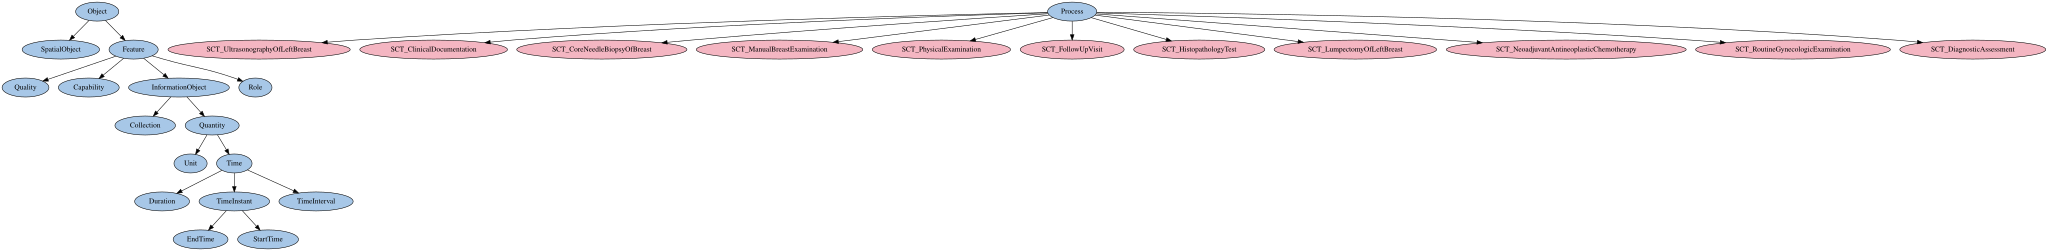

In [9]:
os.makedirs("dist", exist_ok=True)
mie.save(file="dist/mie-01.owl", format="rdfxml")
print("Saved dist/mie-01.owl")
print(f"  classes: {len(list(mie.classes()))}")
print(f"  individuals: {len(list(mie.individuals()))}")
print(f"  object properties (local): {len(list(mie.object_properties()))}")

tree = get_color_tree([sulo, mie])
display(tree)